In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV # Для подбора гиперпараметров случайного леса
from sklearn.tree import DecisionTreeRegressor

import cv2

import os

AttributeError: module 'numpy._globals' has no attribute '_signature_descriptor'

ImportError: numpy._core.multiarray failed to import

## 1. Импортирование данных
Признаки:
- `image_id` - ссылка на картинку дома из папки houses_pics
- `street` - улица, на которой находится дом (адрес)
- `citi` - город (категориальный признак)
- `n_citi` - закодированный через LabelEncoder город (код города)
- `bed` - количество комнат (спален) в доме (числовой признак)
- `bath` - количество ванных комнат в доме (числовой признак)
- `sqft` - площадь дома в квадратных футах (числовой признак)
- `price` - цена дома (целевая переменная)

In [ ]:
df = pd.read_csv('houses.csv')
df

,image_id,street,citi,n_citi,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100
...,...,...,...,...,...,...,...,...
15469,15469,4156 Sterlingview Drive,"Moorpark, CA",227,5,4.1,4092,949000
15470,15470,4355 Avenida Prado,"Thousand Oaks, CA",372,5,3.0,2773,949900
15471,15471,12717 Koenigstein Rd Road,"Santa Paula, CA",338,3,2.0,1576,920000
15472,15472,36 Kunkle Street,"Oak View, CA",253,4,2.0,2086,997000


In [ ]:
df = df.rename(columns={'citi': 'city', 'n_citi': 'encoded_city'})
df

,image_id,street,city,encoded_city,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100
...,...,...,...,...,...,...,...,...
15469,15469,4156 Sterlingview Drive,"Moorpark, CA",227,5,4.1,4092,949000
15470,15470,4355 Avenida Prado,"Thousand Oaks, CA",372,5,3.0,2773,949900
15471,15471,12717 Koenigstein Rd Road,"Santa Paula, CA",338,3,2.0,1576,920000
15472,15472,36 Kunkle Street,"Oak View, CA",253,4,2.0,2086,997000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15474 entries, 0 to 15473
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image_id      15474 non-null  int64  
 1   street        15474 non-null  str    
 2   city          15474 non-null  str    
 3   encoded_city  15474 non-null  int64  
 4   bed           15474 non-null  int64  
 5   bath          15474 non-null  float64
 6   sqft          15474 non-null  int64  
 7   price         15474 non-null  int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 967.3 KB


In [ ]:
df['bath'] = df['bath'].astype('int64')

Пропусков в данных не обнаружено

In [ ]:
df.isnull().sum()

image_id        0
street          0
city            0
encoded_city    0
bed             0
bath            0
sqft            0
price           0
dtype: int64

Дубликатов не обнаружено

In [ ]:
df.duplicated().sum()

np.int64(0)

## 2. Feature Engineering + EDA

Посмотрим кратко на основные показатели данных:

In [ ]:
df.drop('image_id', axis=1).describe()

,encoded_city,bed,bath,sqft,price
count,15474.000000,15474.000000,15474.000000,15474.000000,1.547400e+04
mean,216.597518,3.506398,2.422063,2173.913209,7.031209e+05
std,112.372985,1.034838,0.951160,1025.339617,3.769762e+05
min,0.000000,1.000000,0.000000,280.000000,1.950000e+05
25%,119.000000,3.000000,2.000000,1426.000000,4.450000e+05
50%,222.500000,3.000000,2.000000,1951.000000,6.390000e+05
75%,315.000000,4.000000,3.000000,2737.750000,8.349750e+05
max,414.000000,12.000000,36.000000,17667.000000,2.000000e+06


Создадим несколько новых признаков:
1) `price_per_sqft` - цена за квадратный фут
2) `rooms` - общее число комнат (bed + bath)
3) `avg_room_square` - средняя площадь комнаты

In [ ]:
df['price_per_sqft'] = round(df['price'] / df['sqft'], 2)
df['rooms'] = df['bed'] + df['bath']
df['avg_room_square'] = round(df['sqft'] / df['rooms'], 2)

df

,image_id,street,city,encoded_city,bed,bath,sqft,price,price_per_sqft,rooms,avg_room_square
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2,1560,201900,129.42,5,312.00
1,1,124 C Street W,"Brawley, CA",48,3,2,713,228500,320.48,5,142.60
2,2,2304 Clark Road,"Imperial, CA",152,3,1,800,273950,342.44,4,200.00
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1,1082,350000,323.48,4,270.50
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3,2547,385100,151.20,7,363.86
...,...,...,...,...,...,...,...,...,...,...,...
15469,15469,4156 Sterlingview Drive,"Moorpark, CA",227,5,4,4092,949000,231.92,9,454.67
15470,15470,4355 Avenida Prado,"Thousand Oaks, CA",372,5,3,2773,949900,342.55,8,346.62
15471,15471,12717 Koenigstein Rd Road,"Santa Paula, CA",338,3,2,1576,920000,583.76,5,315.20
15472,15472,36 Kunkle Street,"Oak View, CA",253,4,2,2086,997000,477.95,6,347.67


Посмотрим как средняя цена зависит от местоположения

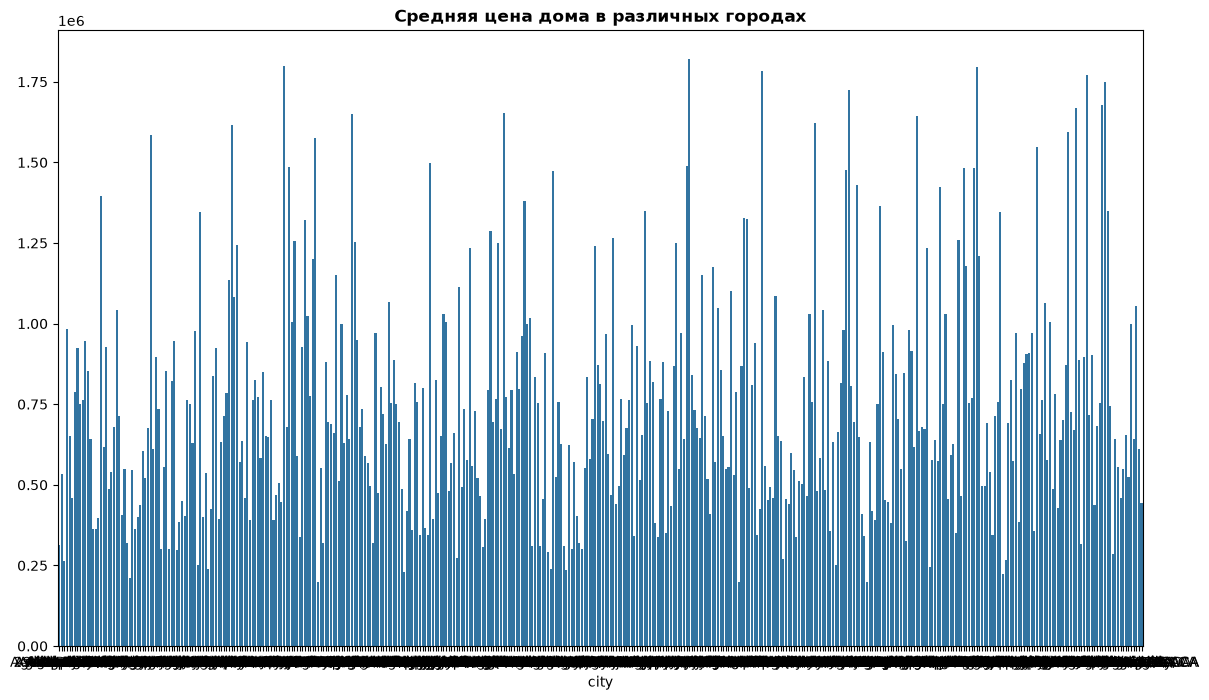

In [ ]:
mean_price_in_cities = df.groupby('city')['price'].mean()

plt.figure(figsize=(14, 8))

sns.barplot(x=mean_price_in_cities.index, y=mean_price_in_cities.values)
plt.title('Средняя цена дома в различных городах', fontweight='bold')

plt.show()

Слишком непонятно и выглядит громоздко + рандомно

Важно отследить, `сколько картинок домов есть в каждом городе`:
- Есть много городов, где маленькое количество домов, значит, в процессе обучения модель будет лучше обучаться на бОльшем количестве домов в конкретных городах, в отличие от городов с маленьким количеством фотографий домов

In [ ]:
number_of_images_per_city = df.groupby('city')['image_id'].count()
sorted_number_of_images_per_city = number_of_images_per_city.sort_values(ascending=False)

sorted_number_of_images_per_city

city
San Diego, CA      707
Los Angeles, CA    388
Lancaster, CA      312
La Quinta, CA      305
Riverside, CA      274
                  ... 
El Mirage, CA        1
Cuyama, CA           1
Blue Jay, CA         1
Echo Park, CA        1
Ocean Beach, CA      1
Name: image_id, Length: 415, dtype: int64

Визуализируем топ 10 городов по средней цене домов, используя группировку, проделанную до этого

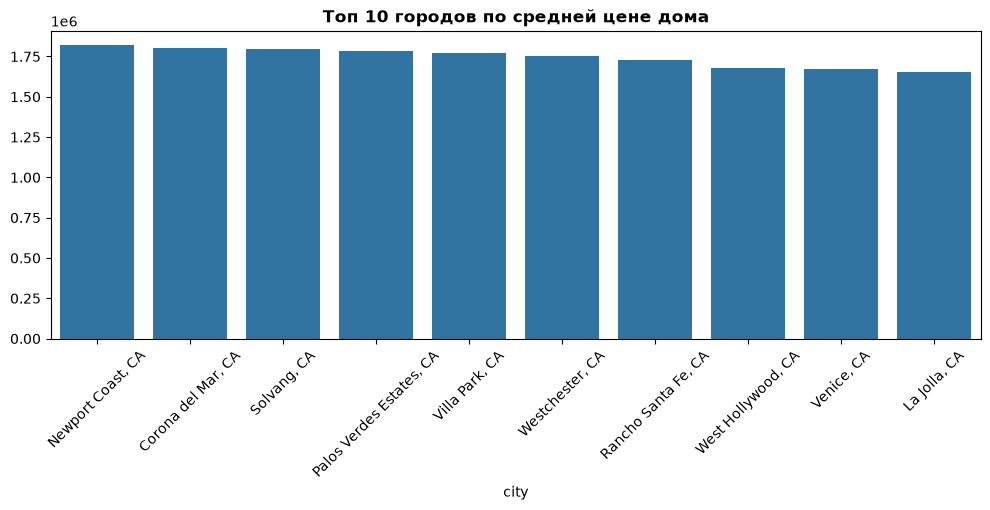

In [ ]:
top10_by_prices = mean_price_in_cities.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 4))

sns.barplot(x=top10_by_prices.index, y=top10_by_prices.values)
plt.xticks(rotation=45)
plt.title('Топ 10 городов по средней цене дома', fontweight='bold')

plt.show()

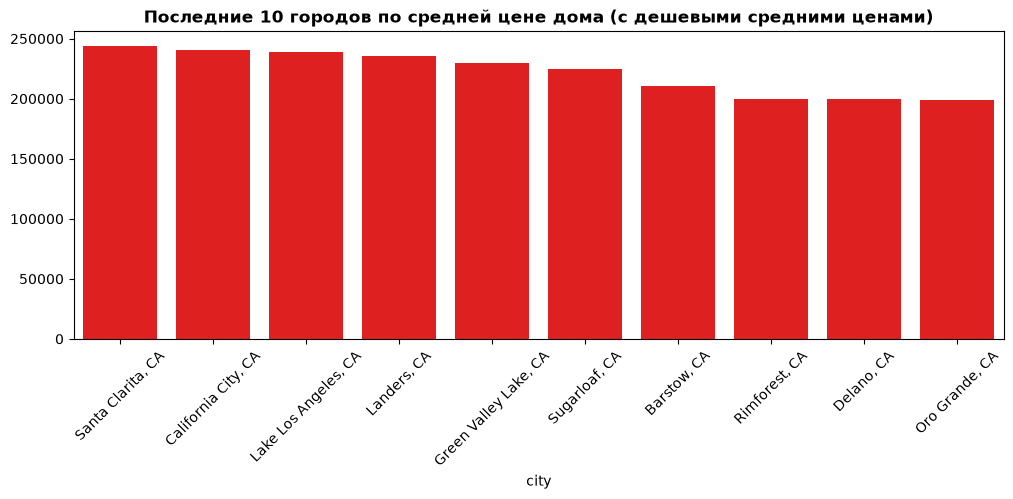

In [ ]:
last10_by_prices = mean_price_in_cities.sort_values(ascending=False).tail(10)

plt.figure(figsize=(12, 4))

sns.barplot(x=last10_by_prices.index, y=last10_by_prices.values, color='red')
plt.xticks(rotation=45)
plt.title('Последние 10 городов по средней цене дома (с дешевыми средними ценами)', fontweight='bold')

plt.show()

**НАБЛЮДЕНИЯ:**
- Заметим, что все эти дорогие дома находятся в **топовых районах** Калифорнии, что подтверждают исследования среди всех штатов.

- **Дешевые дома** находятся вдали от океана и в пустынных районах Калифорнии

- Огромная разница в цене в топовых районах и дорогих (разрыв примерно в 7-8 раз только из-за локации)

Ссылка на статью - (https://lao.ca.gov/LAOEconTax/Article/Detail/793)

Посмотрим в целом распределения признаков:
- Цена (price)
- Количество комнат (rooms)
- Площадь дома (sqft)

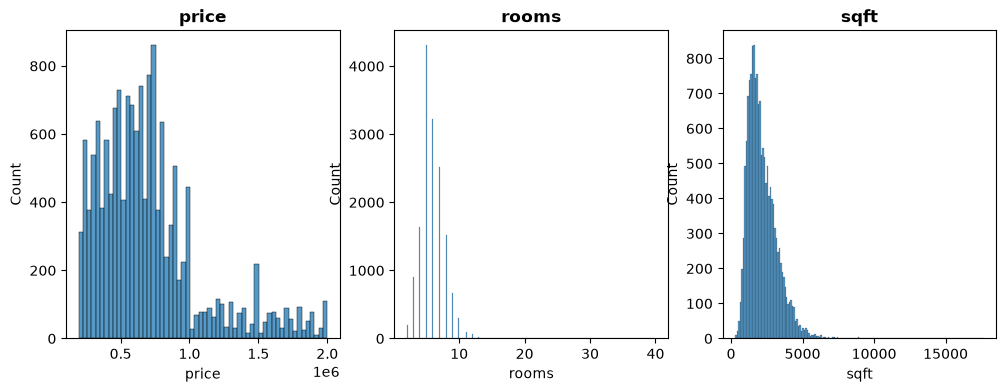

In [ ]:
features = ['price', 'rooms', 'sqft']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, features):
    sns.histplot(data=df, x=col, ax=ax)
    ax.set_title(col, fontweight='bold')

plt.show()

Заметен большой правый хвост в случае цены и квадратных футов, можем прологарифмировать эти признаки, чтобы выровнять их распределения

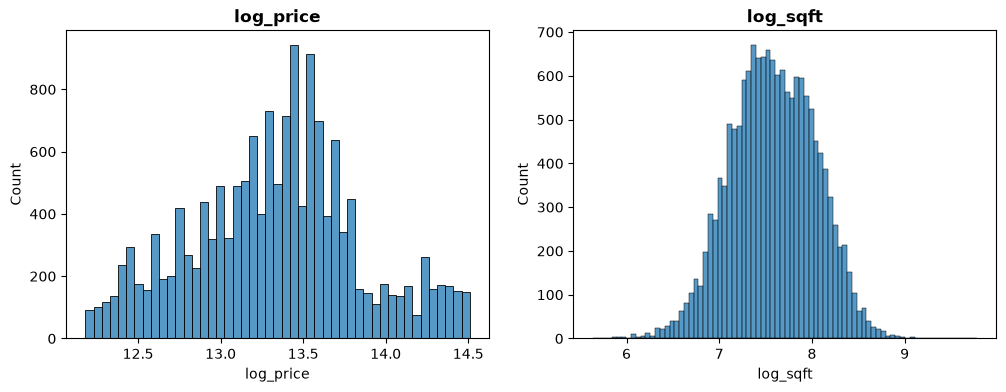

In [ ]:
df['log_price'] = np.log(df['price'])
df['log_sqft'] = np.log(df['sqft'])

log_features = ['log_price', 'log_sqft']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, log_features):
    sns.histplot(data=df, x=col, ax=ax)
    ax.set_title(col, fontweight='bold')

plt.show()

Отлично, теперь их распределения стремятся к нормальным

Посмотрим, как зависит **средняя цена за квадратный фут от количества комнат**

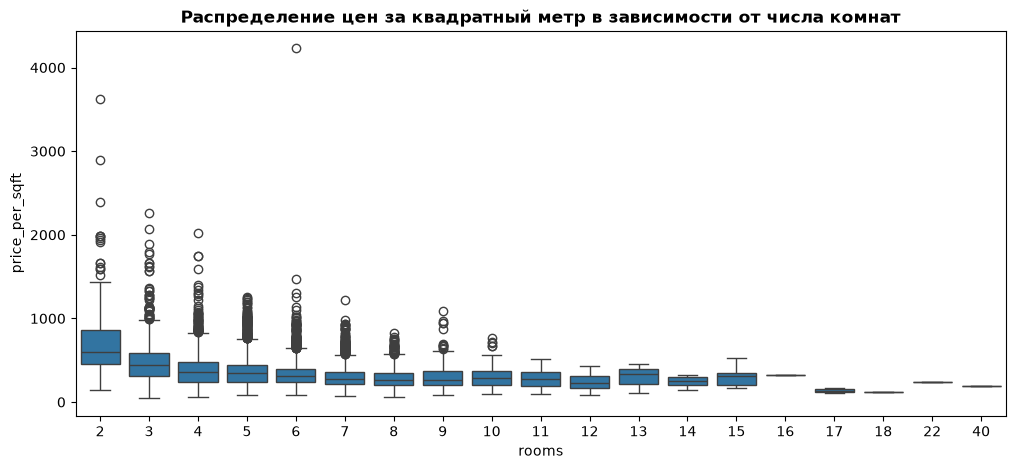

In [ ]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=df, x=df['rooms'], y=df['price_per_sqft'])
plt.title('Распределение цен за квадратный метр в зависимости от числа комнат', fontweight='bold')
plt.show()

**НАБЛЮДЕНИЯ:**

- Цена за квадрат падает с ростом числа комнат
- Разбросы исчезают (аналогично цене) с ростом числа комнат
- В основном присутствуют дома из 2-9 комнат

Теперь в целом посмотрим на линейную зависимость между нашими числовыми признаками:
(**важно**, что фактически несколько признаков дублируются, так как мы логарифмировали)

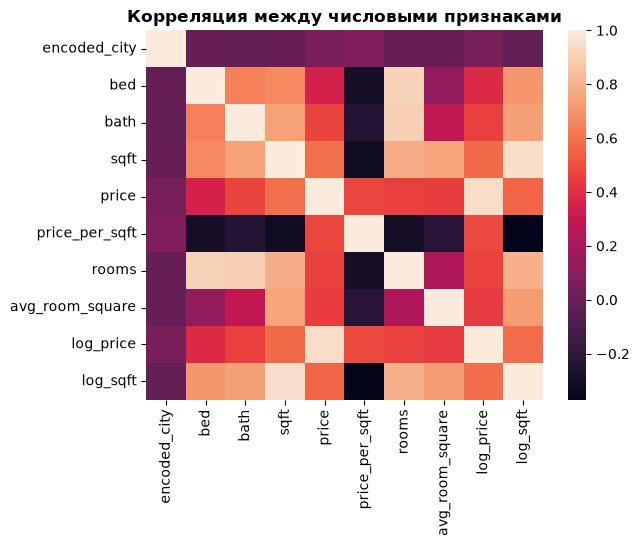

In [ ]:
numeric_features = ['encoded_city', 'bed', 'bath', 'sqft', 'price', 'price_per_sqft', 'rooms', 'avg_room_square', 'log_price', 'log_sqft']
data_with_numb_only = df[numeric_features]

correlations = data_with_numb_only.corr()
sns.heatmap(correlations)
plt.title('Корреляция между числовыми признаками', fontweight='bold')
plt.show()

**НАБЛЮДЕНИЯ:**

- Цена сильнее всего зависит от метража (`sqft`) и числа комнат (`rooms`, `bed`, `bath`) - чем больше дом, тем выше цена. 

- Цена за квадрат (`price_per_sqft`), наоборот, обратно связана с размером: большие дома дешевле в пересчёте на квадратный метр, что подтверждает прошлые наблюдения. 

- Признак `encoded_city` по корреляции неинформативен, так как города закодированы произвольными числами.


Посмотрим чуть больше на зависимость между **площадью и ценой**

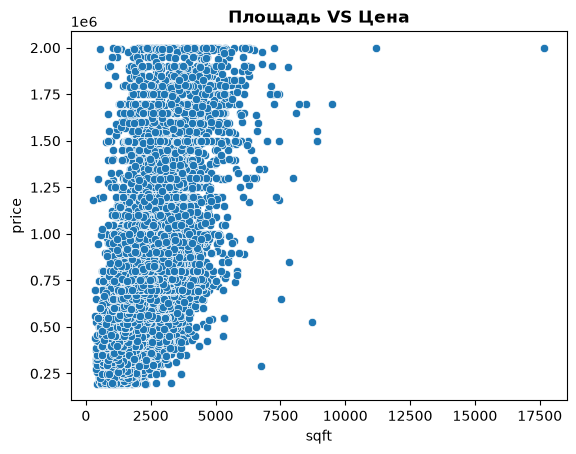

In [ ]:
sns.scatterplot(data=data_with_numb_only, x='sqft', y='price')
plt.title('Площадь VS Цена', fontweight='bold')

plt.show()

Зависимость вообще НЕ линейная, что говорит об относительной хаотичности данных

Теперь рассмотрим остальные зависимости числовых признаков:
- зависимость цены за квадрат от количество ванных комнат, общего числа комнат и другие...

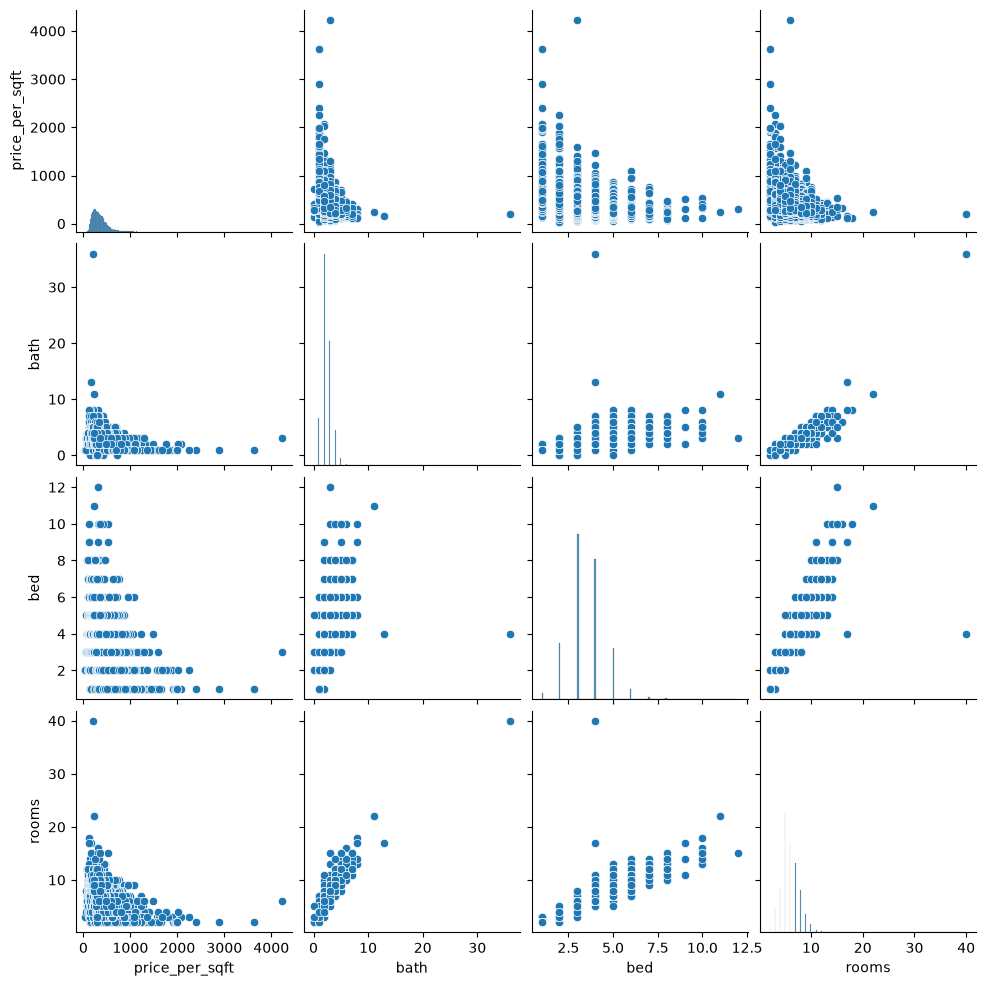

In [ ]:
sns.pairplot(data_with_numb_only[['price_per_sqft', 'bath', 'bed', 'rooms']])

plt.show()

**НАБЛЮДЕНИЯ:**
- `bed`, `bath`, `rooms` — фактически один признак, связаны почти линейно -> мультиколлинеарность, что важно учитывать при построении модели.

- больше комнат - дешевле за квадрат (обратная зависимость), хотя интуитивно кажется, что «больше = дороже», но цена за квадрат ведёт себя наоборот. Большие дома по факту "со скидкой" за квадратные метры

Средний квадратный футаж комнаты зависит почти так же, как и обычная площадь

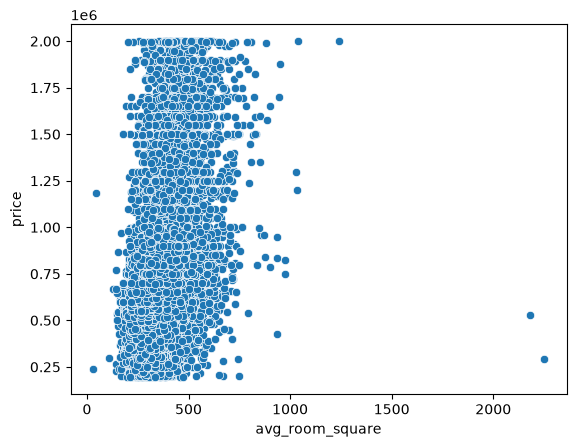

In [ ]:
sns.scatterplot(data=data_with_numb_only, x='avg_room_square', y='price')

plt.show()

## 3. Data preparation for modelling

Обучим модель на числовых признаках и логарифмированных числовых признаках, что поможет решающему дереву минимизировать ошибки в **относительных** величинах. Соответственно, предсказывать мы будем логарифмическое значение цены.

In [ ]:
data = data_with_numb_only.drop(columns=['price_per_sqft', 'price', 'sqft'])
data['log_price'] = round(data['log_price'], 2)
data['log_sqft'] = round(data['log_sqft'], 2)

data

,encoded_city,bed,bath,rooms,avg_room_square,log_price,log_sqft
0,317,3,2,5,312.00,12.22,7.35
1,48,3,2,5,142.60,12.34,6.57
2,152,3,1,4,200.00,12.52,6.68
3,48,3,1,4,270.50,12.77,6.99
4,55,4,3,7,363.86,12.86,7.84
...,...,...,...,...,...,...,...
15469,227,5,4,9,454.67,13.76,8.32
15470,372,5,3,8,346.62,13.76,7.93
15471,338,3,2,5,315.20,13.73,7.36
15472,253,4,2,6,347.67,13.81,7.64


Отделим целевую пременную от остальных

In [ ]:
X = data.drop('log_price', axis=1)
y = data['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X, y

(       encoded_city  bed  bath  rooms  avg_room_square  log_sqft
 0               317    3     2      5           312.00      7.35
 1                48    3     2      5           142.60      6.57
 2               152    3     1      4           200.00      6.68
 3                48    3     1      4           270.50      6.99
 4                55    4     3      7           363.86      7.84
 ...             ...  ...   ...    ...              ...       ...
 15469           227    5     4      9           454.67      8.32
 15470           372    5     3      8           346.62      7.93
 15471           338    3     2      5           315.20      7.36
 15472           253    4     2      6           347.67      7.64
 15473           261    2     2      4           304.00      7.10
 
 [15474 rows x 6 columns],
 0        12.22
 1        12.34
 2        12.52
 3        12.77
 4        12.86
          ...  
 15469    13.76
 15470    13.76
 15471    13.73
 15472    13.81
 15473    13.79
 Na

## 4.1 Baseline

- **Линейная модель** нам не подойдет, поскольку большинство связей нелинейно.

- **Решающие деревья** неплохо улавливают сложные связи, но склонны к переобучению, поэтому есть риск слишком сильно подстроиться под тренировочную выборку при обучении, - это нам тоже не подойдет.

- **<span style="color:yellow">Random forest</span>** - это ансамбль из сотен деревьев, где каждое дерево обучается посредством bootstrap'а, в каждом разбиении случайное подмножество признаков, а итоговый прогноз усредняет предсказания всех деревьев - это отличный вариант для наших данных.

Построим базовую модель на обычном решающем дереве, чтобы после сравнить ее со случайным лесом

In [ ]:
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

def count_metrics(model, X, y):
    y_pred = model.predict(X)

    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print(f'MSE={mse}, MAE={mae}, Коэффициент детерминации: {r2}')
    return round(mse, 5), round(mae, 5), round(r2, 5)


print('Метркии на тестовой выборке: ')
count_metrics(decision_tree_model, X_test, y_test)

Метркии на тестовой выборке: 
MSE=0.13470244593633993, MAE=0.21837703968083033, Коэффициент детерминации: 0.48341301327914


(0.1347, 0.21838, 0.48341)

Улучшим нашу модель **в следующем разделе**, используя случайный лес

## 4.2 Оптимизация модели с подбором гиперпараметров

- `n_estimators` - количество решающих деревьев в ансамбле.

- `max_depth` - максимальная глубина дерева, по умолчанию None, то есть деревья растут до конца. В лесу глубокие деревья не так страшны, как в одиночном, потому что усреднение гасит переобучение, но иногда ограничение помогает и ускоряет.

- `min_samples_leaf` - минимум объектов в листе. Больше значение -> глаже деревья, меньше переобучения.

- `min_samples_split` - минимум объектов, чтобы делить вершину. Помогает сдерживать рост.

In [ ]:
model = RandomForestRegressor(random_state=42)

parameters = {
    'n_estimators': [50, 100, 200, 250, 300],
    'max_depth': [None, 5, 8, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20],
}

grid = GridSearchCV(
    model,
    parameters,
    cv=5, # по 5 фолдов для кросс-валидации
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=2.0.0 and <2.8.0 is required for this version of SciPy (detected version 1.26.4)
  from scipy.sparse import csr_array, issparse
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=2.0.0 and <2.8.0 is required for this version of SciPy (detected version 1.26.4)
  from scipy.sparse import csr_array, issparse
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=2.0.0 and <2.8.0 is required for this version of SciPy (detected version 1.26.4)
  from scipy.sparse import csr_array, issparse
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=2.0.0 and <2.8.0 is required for this version of SciPy (detected version 1.26.4)
  from scipy.sparse import csr_array, issparse
/opt/anaconda3/lib/python3.12/si

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
print('Лучшие параметры: ', grid.best_params_)

Лучшие параметры:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
best_random_forest_model = grid.best_estimator_
best_random_forest_model.fit(X_train, y_train)

count_metrics(best_random_forest_model, X_test, y_test)

MSE=0.08525518074402579, MAE=0.20132780573516054, Коэффициент детерминации: 0.6730444156618167


(0.08526, 0.20133, 0.67304)

**ВЫВОД:**
- Результат <u>отличный</u> - значительно снизилась MSE и коэффициент дтерминации вырос почти в 1.5 раза, то есть лес может объяснить 67% вариации цены против 48% у обычного дерева решений.

- Модель случайного леса повысила эффективность предсказаний и была корректно выбрана.